In [1]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
import pandas as pd
import datetime
import copy
# import seaborn as sns
import colorcet as cc
# from sklearn.neighbors import KernelDensity
import warnings

In [412]:
# start_date = '20181129'
# ens_member = 'gefs00'
# ens_member = 'gefs03'
# ens_member = 'gefs18'
# ens_member = 'gefs09'

# start_date = '20181204'
# ens_member = 'gefs18'
# ens_member = 'gefs19'

# start_date = '20181219'
# ens_member = 'eda09'

# start_date = '20190122'
# ens_member = 'gefs01'
# ens_member = 'gefs18'

# start_date = '20190123'
# ens_member = 'eda05'
# ens_member = 'gefs18'

# start_date = '20190129'
# ens_member = 'eda09'
# ens_member = 'gefs11'

start_date = '20190208'
# ens_member = 'eda03'
ens_member = 'eda08'

In [413]:
# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_2location_'

figdir = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/{start_date}_{ens_member}/'
os.makedirs(figdir, exist_ok=True)

# Domain 4 boundaries
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Environment location (0: fixed site, 1: CI location)
env_loc = 1

file_d2 = glob.glob(f'{rootdir_meso}{start_date}/{ens_member}/base/d2/stats/{in_basename}*.nc')[0]
file_d3 = glob.glob(f'{rootdir_les}{start_date}/{ens_member}/base/d3/stats/{in_basename}*.nc')[0]
file_d4 = glob.glob(f'{rootdir_les}{start_date}/{ens_member}/base/d4/stats/{in_basename}*.nc')[0]

efile_d2 = glob.glob(f'{rootdir_meso}{start_date}/{ens_member}/base/d2/stats/{in_basename_env}*.nc')[0]
efile_d3 = glob.glob(f'{rootdir_les}{start_date}/{ens_member}/base/d3/stats/{in_basename_env}*.nc')[0]
efile_d4 = glob.glob(f'{rootdir_les}{start_date}/{ens_member}/base/d4/stats/{in_basename_env}*.nc')[0]

In [414]:
file_d2, file_d3, file_d4

('/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20190208/eda08/base/d2/stats/trackstats_20190208.1200_20190209.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda08/base/d3/stats/trackstats_20190208.1200_20190209.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda08/base/d4/stats/trackstats_20190208.1200_20190209.0000.nc')

In [415]:
efile_d2, efile_d3, efile_d4

('/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20190208/eda08/base/d2/stats/stats_1d_env_2location_20190208.1200_20190209.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda08/base/d3/stats/stats_1d_env_2location_20190208.1200_20190209.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda08/base/d4/stats/stats_1d_env_2location_20190208.1200_20190209.0000.nc')

## Read and combine data files

In [416]:
# Concatenante the DataSets along the 'tracks' dimension
dst_d2 = xr.open_dataset(file_d2)
ntracks_d2 = dst_d2.sizes['tracks']

# Read ENV data
dse_d2 = xr.open_dataset(efile_d2).sel(location=env_loc)

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dse_d2], combine_attrs='drop_conflicts')
ds_d2

<xarray.Dataset>
Dimensions:                  (tracks: 367, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 5 ... 362 363 364 365 366
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
    location                 int64 1
Data variables: (12/172)
    temperature              (tracks, times, height) float32 nan nan ... nan nan
    qv                       (tracks, times, height) float32 nan nan ... nan nan
    rh                       (tracks, times, height) float32 nan nan ... nan nan
    pressure                 (tracks, times, height) float32 nan nan ... nan nan
    u                        (tracks, times, height) float32 nan nan ... nan nan
    v                        (tracks, times, height) float32 nan nan ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 ...
    start_split_timeindex    (tracks) float64 ...
    start_split_cloudnumber  (tracks) float64 ...
    end_merge_tracknumber    (tracks) float64 ...
    end_merge_timeindex      (tracks) float64 ...
    end_merge_cloudnumber    (tracks) float64 ...
Attributes:
    startdate:             20190208.1200
    enddate:               20190209.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [417]:
# Concatenante the DataSets along the 'tracks' dimension
dst_d3 = xr.open_dataset(file_d3)
ntracks_d3 = dst_d3.sizes['tracks']

# Read ENV data
dse_d3 = xr.open_dataset(efile_d3).sel(location=env_loc)

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dse_d3], combine_attrs='drop_conflicts')
ds_d3

<xarray.Dataset>
Dimensions:                  (tracks: 635, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 5 ... 630 631 632 633 634
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
    location                 int64 1
Data variables: (12/172)
    temperature              (tracks, times, height) float32 nan nan ... nan nan
    qv                       (tracks, times, height) float32 nan nan ... nan nan
    rh                       (tracks, times, height) float32 nan nan ... nan nan
    pressure                 (tracks, times, height) float32 nan nan ... nan nan
    u                        (tracks, times, height) float32 nan nan ... nan nan
    v                        (tracks, times, height) float32 nan nan ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 ...
    start_split_timeindex    (tracks) float64 ...
    start_split_cloudnumber  (tracks) float64 ...
    end_merge_tracknumber    (tracks) float64 ...
    end_merge_timeindex      (tracks) float64 ...
    end_merge_cloudnumber    (tracks) float64 ...
Attributes:
    startdate:             20190208.1200
    enddate:               20190209.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [418]:
# Concatenante the DataSets along the 'tracks' dimension
dst_d4 = xr.open_dataset(file_d4)
ntracks_d4 = dst_d4.sizes['tracks']

# Read ENV data
dse_d4 = xr.open_dataset(efile_d4).sel(location=env_loc)

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dse_d4], combine_attrs='drop_conflicts')
ds_d4

<xarray.Dataset>
Dimensions:                  (tracks: 434, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 5 ... 429 430 431 432 433
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
    location                 int64 1
Data variables: (12/172)
    temperature              (tracks, times, height) float32 nan nan ... nan nan
    qv                       (tracks, times, height) float32 nan nan ... nan nan
    rh                       (tracks, times, height) float32 nan nan ... nan nan
    pressure                 (tracks, times, height) float32 nan nan ... nan nan
    u                        (tracks, times, height) float32 nan nan ... nan nan
    v                        (tracks, times, height) float32 nan nan ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 ...
    start_split_timeindex    (tracks) float64 ...
    start_split_cloudnumber  (tracks) float64 ...
    end_merge_tracknumber    (tracks) float64 ...
    end_merge_timeindex      (tracks) float64 ...
    end_merge_cloudnumber    (tracks) float64 ...
Attributes:
    startdate:             20190208.1200
    enddate:               20190209.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [419]:
# Cell diameter
cellarea_d2 = ds_d2['cell_area'].load()
cellarea_d3 = ds_d3['cell_area'].load()
cellarea_d4 = ds_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

# Add cell diameter to the DataSets
celldiam_d2.attrs = {'long_name':'Cell equivalent diameter', 'units':'km'}
ds_d2['cell_diameter'] = celldiam_d2
celldiam_d3.attrs = {'long_name':'Cell equivalent diameter', 'units':'km'}
ds_d3['cell_diameter'] = celldiam_d3
celldiam_d4.attrs = {'long_name':'Cell equivalent diameter', 'units':'km'}
ds_d4['cell_diameter'] = celldiam_d4

In [420]:
# celldiam_d4.attrs = {'long_name':'Cell equivalent diameter', 'units':'km'}
# ds_d4['cell_diameter'] = celldiam_d4

## Subset tracks

In [421]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
height = ds_d2.height / 1000.

In [422]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
lifetime_d2 = (ds_d2['track_duration'] * time_res).load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)) & \
                    (lifetime_d2 >= min(lifetime_range) & (lifetime_d2 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 178


In [423]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
lifetime_d3 = (ds_d3['track_duration'] * time_res).load()
# Subset d3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)) & \
                    (lifetime_d3 >= min(lifetime_range) & (lifetime_d3 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (d3): {ntracks_d3}')

Number of tracks (d3): 298


In [424]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
lifetime_d4 = (ds_d4['track_duration'] * time_res).load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)) & \
                    (lifetime_d4 >= min(lifetime_range) & (lifetime_d4 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (d4): {ntracks_d4}')

Number of tracks (d4): 265


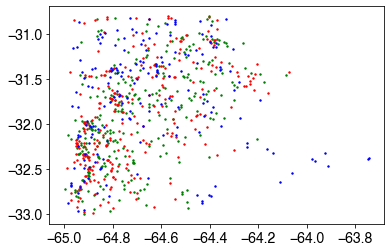

In [425]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

## Find merge/split track indices

In [426]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [427]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

## Subset DataSets with non-merge/non-split tracks

In [428]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 94
D3 non-merge-split tracks: 133
D4 non-merge-split tracks: 151


In [429]:
# Get preCI MU LNB
preCI_time = -3  # preCI time
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d2 = ((dsnms_d2.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d3 = ((dsnms_d3.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d4 = ((dsnms_d4.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)

## Thresholds to define narrow vs. wide cells (from ALL cases)

In [430]:
# Max 10dBZ percentile values (D2):
max10dbz_pts_d2 = [4., 4.75, 6.]
# Max CellDiam percentile values (D2): 
maxCellDiam_pts_d2 = [9.7720499, 10.17107201, 11.96826839]

# Max 10dBZ percentile values (D3):
max10dbz_pts_d3 = [5.25, 6., 7.]
# Max CellDiam percentile values (D3): 
maxCellDiam_pts_d3 = [4.95074368, 5.58519173, 6.635397]

# Max 10dBZ percentile values (D4): 
max10dbz_pts_d4 = [5., 5.5, 6.5]
# Max CellDiam percentile values (D4): 
maxCellDiam_pts_d4 = [4.90810179, 5.41151619, 6.28254938]

## Separate narrow vs. wide cell DataSets

In [431]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]

In [432]:
# Define narrow vs. wide thresholds
narrow_diam_d2 = maxCellDiam_pts_d2[0]
wide_diam_d2 = maxCellDiam_pts_d2[2]
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# ds_d2.cell_diameter
trackmaxCellDiam_d2 = dsnms_d2.cell_diameter.max(dim='times')
# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 <= narrow_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# For all tracks
alltrackmaxCellDiam_d2 = ds_d2.cell_diameter.max(dim='times')
# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
allnarrow_tracks_d2 = (alltrackmaxCellDiam_d2 <= narrow_diam_d2).compute()
allwide_tracks_d2 = (alltrackmaxCellDiam_d2>= wide_diam_d2).compute()
# Subset DataSets
dsall_narrow_d2 = ds_d2.where(allnarrow_tracks_d2, drop=True)
dsall_wide_d2 = ds_d2.where(allwide_tracks_d2, drop=True)
ntracks_allnarrow_d2 = dsall_narrow_d2.sizes['tracks']
ntracks_allwide_d2 = dsall_wide_d2.sizes['tracks']
print(f'Number of all narrow cells (D2): {ntracks_allnarrow_d2}')
print(f'Number of all wide cells (D2): {ntracks_allwide_d2}')

Narrow diameter threshold (D2): 9.77 km
Wide diameter threshold (D2): 11.97 km
Number of narrow cells (D2): 56
Number of wide cells (D2): 29
Number of all narrow cells (D2): 79
Number of all wide cells (D2): 74


In [433]:
# Define narrow vs. wide thresholds
narrow_diam_d3 = maxCellDiam_pts_d3[0]
wide_diam_d3 = maxCellDiam_pts_d3[2]
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.02f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.02f} km')

# ds_d3.cell_diameter
trackmaxCellDiam_d3 = dsnms_d3.cell_diameter.max(dim='times')
# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 <= narrow_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# For all tracks
alltrackmaxCellDiam_d3 = ds_d3.cell_diameter.max(dim='times')
# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
allnarrow_tracks_d3 = (alltrackmaxCellDiam_d3 <= narrow_diam_d3).compute()
allwide_tracks_d3 = (alltrackmaxCellDiam_d3>= wide_diam_d3).compute()
# Subset DataSets
dsall_narrow_d3 = ds_d3.where(allnarrow_tracks_d3, drop=True)
dsall_wide_d3 = ds_d3.where(allwide_tracks_d3, drop=True)
ntracks_allnarrow_d3 = dsall_narrow_d3.sizes['tracks']
ntracks_allwide_d3 = dsall_wide_d3.sizes['tracks']
print(f'Number of all narrow cells (d3): {ntracks_allnarrow_d3}')
print(f'Number of all wide cells (d3): {ntracks_allwide_d3}')

Narrow diameter threshold (D3): 4.95 km
Wide diameter threshold (D3): 6.64 km
Number of narrow cells (D3): 45
Number of wide cells (D3): 48
Number of all narrow cells (d3): 70
Number of all wide cells (d3): 153


In [434]:
# Define narrow vs. wide thresholds
narrow_diam_d4 = maxCellDiam_pts_d4[0]
wide_diam_d4 = maxCellDiam_pts_d4[2]
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.02f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.02f} km')

# ds_d4.cell_diameter
trackmaxCellDiam_d4 = dsnms_d4.cell_diameter.max(dim='times')
# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 <= narrow_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# For all tracks
alltrackmaxCellDiam_d4 = ds_d4.cell_diameter.max(dim='times')
# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
allnarrow_tracks_d4 = (alltrackmaxCellDiam_d4 <= narrow_diam_d4).compute()
allwide_tracks_d4 = (alltrackmaxCellDiam_d4>= wide_diam_d4).compute()
# Subset DataSets
dsall_narrow_d4 = ds_d4.where(allnarrow_tracks_d4, drop=True)
dsall_wide_d4 = ds_d4.where(allwide_tracks_d4, drop=True)
ntracks_allnarrow_d4 = dsall_narrow_d4.sizes['tracks']
ntracks_allwide_d4 = dsall_wide_d4.sizes['tracks']
print(f'Number of all narrow cells (d4): {ntracks_allnarrow_d4}')
print(f'Number of all wide cells (d4): {ntracks_allwide_d4}')

Narrow diameter threshold (D4): 4.91 km
Wide diameter threshold (D4): 6.28 km
Number of narrow cells (D4): 54
Number of wide cells (D4): 43
Number of all narrow cells (d4): 76
Number of all wide cells (d4): 113


In [435]:
# Set start_basetime as a coordinate in the DataSet
ds_narrow_d2 = ds_narrow_d2.set_coords('start_basetime')
ds_wide_d2 = ds_wide_d2.set_coords('start_basetime')

dsall_narrow_d2 = dsall_narrow_d2.set_coords('start_basetime')
dsall_wide_d2 = dsall_wide_d2.set_coords('start_basetime')

In [436]:
# Set start_basetime as a coordinate in the DataSet
ds_narrow_d3 = ds_narrow_d3.set_coords('start_basetime')
ds_wide_d3 = ds_wide_d3.set_coords('start_basetime')

dsall_narrow_d3 = dsall_narrow_d3.set_coords('start_basetime')
dsall_wide_d3 = dsall_wide_d3.set_coords('start_basetime')

In [437]:
# Set start_basetime as a coordinate in the DataSet
ds_narrow_d4 = ds_narrow_d4.set_coords('start_basetime')
ds_wide_d4 = ds_wide_d4.set_coords('start_basetime')

dsall_narrow_d4 = dsall_narrow_d4.set_coords('start_basetime')
dsall_wide_d4 = dsall_wide_d4.set_coords('start_basetime')

In [438]:
# Get start time for the case
start_time = pd.to_datetime(f'{start_date}T12', format='%Y%m%dT%H')
# Normalize start_time and set it to midnight, then add 1 day
end_time = start_time.normalize() + pd.Timedelta(days=1)
# Define the time bins
freq = '2h'
# freq = '1h'
time_bins = pd.date_range(start=start_time, end=end_time, freq=freq)
time_bins

# Create IntervalIndex for the time bins
intervals = pd.IntervalIndex.from_breaks(time_bins)
# Calculate the center of each interval
time_bins_c = intervals.left + (intervals.right - intervals.left) / 2
# Convert to local time (UTC-3)
time_bins_lt = time_bins_c - pd.Timedelta(hours=3)

In [439]:
count_narrow_d2 = ds_narrow_d2['tracks'].groupby_bins('start_basetime', bins=time_bins).count()
count_wide_d2 = ds_wide_d2['tracks'].groupby_bins('start_basetime', bins=time_bins).count()

count_allnarrow_d2 = dsall_narrow_d2['tracks'].groupby_bins('start_basetime', bins=time_bins).count()
count_allwide_d2 = dsall_wide_d2['tracks'].groupby_bins('start_basetime', bins=time_bins).count()

In [440]:
count_narrow_d3 = ds_narrow_d3['tracks'].groupby_bins('start_basetime', bins=time_bins).count()
count_wide_d3 = ds_wide_d3['tracks'].groupby_bins('start_basetime', bins=time_bins).count()

count_allnarrow_d3 = dsall_narrow_d3['tracks'].groupby_bins('start_basetime', bins=time_bins).count()
count_allwide_d3 = dsall_wide_d3['tracks'].groupby_bins('start_basetime', bins=time_bins).count()

In [441]:
count_narrow_d4 = ds_narrow_d4['tracks'].groupby_bins('start_basetime', bins=time_bins).count()
count_wide_d4 = ds_wide_d4['tracks'].groupby_bins('start_basetime', bins=time_bins).count()

count_allnarrow_d4 = dsall_narrow_d4['tracks'].groupby_bins('start_basetime', bins=time_bins).count()
count_allwide_d4 = dsall_wide_d4['tracks'].groupby_bins('start_basetime', bins=time_bins).count()

In [442]:
def get_timeseries(da, time_bins, percentiles):
    da_med = da.groupby_bins('start_basetime', bins=time_bins).median()
    da_iqr = da.groupby_bins('start_basetime', bins=time_bins).quantile(percentiles).transpose()
    # Divide median value to get fraction for lower/upper bounds
    # da_err = da_iqr / da_med
    da_err = [np.abs(da_iqr[0] - da_med), np.abs(da_iqr[1] - da_med)]
    return da_med, da_err

In [443]:
# da = ds_narrow_d2['maxETH_10dbz'].max(dim='times')
# da_med = da.groupby_bins('start_basetime', bins=time_bins).median()
# da_iqr = da.groupby_bins('start_basetime', bins=time_bins).quantile(percentiles).transpose()

# # # err = [da_iqr.data[0]-da_med.data, da_iqr.data[1]-da_med.data]
# # err = [da_iqr.data[0]/da_med.data, da_iqr.data[1]/da_med.data]
# err = [np.abs(da_iqr[0] - da_med), np.abs(da_iqr[1] - da_med)]
# da_med.data, err

In [444]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

percentiles = [0.25, 0.75]
narrow_maxcellDiam_d2, narrow_maxcellDiam_err_d2 = get_timeseries(ds_narrow_d2['cell_diameter'].max(dim='times'), time_bins, percentiles)
narrow_maxETH10dbz_d2, narrow_maxETH10dbz_err_d2 = get_timeseries(ds_narrow_d2['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

wide_maxcellDiam_d2, wide_maxcellDiam_err_d2 = get_timeseries(ds_wide_d2['cell_diameter'].max(dim='times'), time_bins, percentiles)
wide_maxETH10dbz_d2, wide_maxETH10dbz_err_d2 = get_timeseries(ds_wide_d2['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d2, narrow_pELmu_err_d2 = get_timeseries((ds_narrow_d2.pEL_height_mu).sel(times=preCI_time)/1000, time_bins, percentiles)
narrow_pCAPEmu_d2, narrow_pCAPEmu_err_d2 = get_timeseries(ds_narrow_d2.pCAPE_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_pCAPEacbl_d2, narrow_pCAPEacbl_err_d2 = get_timeseries(ds_narrow_d2.pCAPEacbl_ml.sel(times=preCI_time), time_bins, percentiles)
narrow_pCINmu_d2, narrow_pCINmu_err_d2 = get_timeseries(ds_narrow_d2.pCIN_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_LCLz_d2, narrow_LCLz_err_d2 = get_timeseries(ds_narrow_d2.LCL_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
narrow_LCLt_d2, narrow_LCLt_err_d2 = get_timeseries(ds_narrow_d2.LCL_temp_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_pLFCz_d2, narrow_pLFCz_err_d2 = get_timeseries(ds_narrow_d2.pLFC_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
# Moisture
narrow_RHacbl_d2, narrow_RHacbl_err_d2 = get_timeseries(ds_narrow_d2.RH_mean_ACBL.sel(times=preCI_time), time_bins, percentiles)
narrow_RH600mb_d2, narrow_RH600mb_err_d2 = get_timeseries(ds_narrow_d2.rh_600mb.sel(times=preCI_time), time_bins, percentiles)
narrow_RH500mb_d2, narrow_RH500mb_err_d2 = get_timeseries(ds_narrow_d2.rh_500mb.sel(times=preCI_time), time_bins, percentiles)
narrow_RH5km_d2, narrow_RH5km_err_d2 = get_timeseries(ds_narrow_d2.rh_5000masl.sel(times=preCI_time), time_bins, percentiles)
narrow_RHlfc1500_d2, narrow_RHlfc1500_err_d2 = get_timeseries(ds_narrow_d2.rh_at_pmuLFCplus1500m.sel(times=preCI_time), time_bins, percentiles)
narrow_PW_d2, narrow_PW_err_d2 = get_timeseries(ds_narrow_d2.PW.sel(times=preCI_time), time_bins, percentiles)

# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d2, wide_pELmu_err_d2 = get_timeseries((ds_wide_d2.pEL_height_mu).sel(times=preCI_time)/1000, time_bins, percentiles)
wide_pCAPEmu_d2, wide_pCAPEmu_err_d2 = get_timeseries(ds_wide_d2.pCAPE_mu.sel(times=preCI_time), time_bins, percentiles)
wide_pCAPEacbl_d2, wide_pCAPEacbl_err_d2 = get_timeseries(ds_wide_d2.pCAPEacbl_ml.sel(times=preCI_time), time_bins, percentiles)
wide_pCINmu_d2, wide_pCINmu_err_d2 = get_timeseries(ds_wide_d2.pCIN_mu.sel(times=preCI_time), time_bins, percentiles)
wide_LCLz_d2, wide_LCLz_err_d2 = get_timeseries(ds_wide_d2.LCL_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
wide_LCLt_d2, wide_LCLt_err_d2 = get_timeseries(ds_wide_d2.LCL_temp_mu.sel(times=preCI_time), time_bins, percentiles)
wide_pLFCz_d2, wide_pLFCz_err_d2 = get_timeseries(ds_wide_d2.pLFC_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
# Moisture
wide_RHacbl_d2, wide_RHacbl_err_d2 = get_timeseries(ds_wide_d2.RH_mean_ACBL.sel(times=preCI_time), time_bins, percentiles)
wide_RH600mb_d2, wide_RH600mb_err_d2 = get_timeseries(ds_wide_d2.rh_600mb.sel(times=preCI_time), time_bins, percentiles)
wide_RH500mb_d2, wide_RH500mb_err_d2 = get_timeseries(ds_wide_d2.rh_500mb.sel(times=preCI_time), time_bins, percentiles)
wide_RH5km_d2, wide_RH5km_err_d2 = get_timeseries(ds_wide_d2.rh_5000masl.sel(times=preCI_time), time_bins, percentiles)
wide_RHlfc1500_d2, wide_RHlfc1500_err_d2 = get_timeseries(ds_wide_d2.rh_at_pmuLFCplus1500m.sel(times=preCI_time), time_bins, percentiles)
wide_PW_d2, wide_PW_err_d2 = get_timeseries(ds_wide_d2.PW.sel(times=preCI_time), time_bins, percentiles)

In [445]:
narrow_maxcellDiam_d3, narrow_maxcellDiam_err_d3 = get_timeseries(ds_narrow_d3['cell_diameter'].max(dim='times'), time_bins, percentiles)
narrow_maxETH10dbz_d3, narrow_maxETH10dbz_err_d3 = get_timeseries(ds_narrow_d3['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

wide_maxcellDiam_d3, wide_maxcellDiam_err_d3 = get_timeseries(ds_wide_d3['cell_diameter'].max(dim='times'), time_bins, percentiles)
wide_maxETH10dbz_d3, wide_maxETH10dbz_err_d3 = get_timeseries(ds_wide_d3['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d3, narrow_pELmu_err_d3 = get_timeseries((ds_narrow_d3.pEL_height_mu).sel(times=preCI_time)/1000, time_bins, percentiles)
narrow_pCAPEmu_d3, narrow_pCAPEmu_err_d3 = get_timeseries(ds_narrow_d3.pCAPE_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_pCAPEacbl_d3, narrow_pCAPEacbl_err_d3 = get_timeseries(ds_narrow_d3.pCAPEacbl_ml.sel(times=preCI_time), time_bins, percentiles)
narrow_pCINmu_d3, narrow_pCINmu_err_d3 = get_timeseries(ds_narrow_d3.pCIN_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_LCLz_d3, narrow_LCLz_err_d3 = get_timeseries(ds_narrow_d3.LCL_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
narrow_LCLt_d3, narrow_LCLt_err_d3 = get_timeseries(ds_narrow_d3.LCL_temp_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_pLFCz_d3, narrow_pLFCz_err_d3 = get_timeseries(ds_narrow_d3.pLFC_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
# Moisture
narrow_RHacbl_d3, narrow_RHacbl_err_d3 = get_timeseries(ds_narrow_d3.RH_mean_ACBL.sel(times=preCI_time), time_bins, percentiles)
narrow_RH600mb_d3, narrow_RH600mb_err_d3 = get_timeseries(ds_narrow_d3.rh_600mb.sel(times=preCI_time), time_bins, percentiles)
narrow_RH500mb_d3, narrow_RH500mb_err_d3 = get_timeseries(ds_narrow_d3.rh_500mb.sel(times=preCI_time), time_bins, percentiles)
narrow_RH5km_d3, narrow_RH5km_err_d3 = get_timeseries(ds_narrow_d3.rh_5000masl.sel(times=preCI_time), time_bins, percentiles)
narrow_RHlfc1500_d3, narrow_RHlfc1500_err_d3 = get_timeseries(ds_narrow_d3.rh_at_pmuLFCplus1500m.sel(times=preCI_time), time_bins, percentiles)
narrow_PW_d3, narrow_PW_err_d3 = get_timeseries(ds_narrow_d3.PW.sel(times=preCI_time), time_bins, percentiles)

# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d3, wide_pELmu_err_d3 = get_timeseries((ds_wide_d3.pEL_height_mu).sel(times=preCI_time)/1000, time_bins, percentiles)
wide_pCAPEmu_d3, wide_pCAPEmu_err_d3 = get_timeseries(ds_wide_d3.pCAPE_mu.sel(times=preCI_time), time_bins, percentiles)
wide_pCAPEacbl_d3, wide_pCAPEacbl_err_d3 = get_timeseries(ds_wide_d3.pCAPEacbl_ml.sel(times=preCI_time), time_bins, percentiles)
wide_pCINmu_d3, wide_pCINmu_err_d3 = get_timeseries(ds_wide_d3.pCIN_mu.sel(times=preCI_time), time_bins, percentiles)
wide_LCLz_d3, wide_LCLz_err_d3 = get_timeseries(ds_wide_d3.LCL_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
wide_LCLt_d3, wide_LCLt_err_d3 = get_timeseries(ds_wide_d3.LCL_temp_mu.sel(times=preCI_time), time_bins, percentiles)
wide_pLFCz_d3, wide_pLFCz_err_d3 = get_timeseries(ds_wide_d3.pLFC_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
# Moisture
wide_RHacbl_d3, wide_RHacbl_err_d3 = get_timeseries(ds_wide_d3.RH_mean_ACBL.sel(times=preCI_time), time_bins, percentiles)
wide_RH600mb_d3, wide_RH600mb_err_d3 = get_timeseries(ds_wide_d3.rh_600mb.sel(times=preCI_time), time_bins, percentiles)
wide_RH500mb_d3, wide_RH500mb_err_d3 = get_timeseries(ds_wide_d3.rh_500mb.sel(times=preCI_time), time_bins, percentiles)
wide_RH5km_d3, wide_RH5km_err_d3 = get_timeseries(ds_wide_d3.rh_5000masl.sel(times=preCI_time), time_bins, percentiles)
wide_RHlfc1500_d3, wide_RHlfc1500_err_d3 = get_timeseries(ds_wide_d3.rh_at_pmuLFCplus1500m.sel(times=preCI_time), time_bins, percentiles)
wide_PW_d3, wide_PW_err_d3 = get_timeseries(ds_wide_d3.PW.sel(times=preCI_time), time_bins, percentiles)

In [446]:
narrow_maxcellDiam_d4, narrow_maxcellDiam_err_d4 = get_timeseries(ds_narrow_d4['cell_diameter'].max(dim='times'), time_bins, percentiles)
narrow_maxETH10dbz_d4, narrow_maxETH10dbz_err_d4 = get_timeseries(ds_narrow_d4['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

wide_maxcellDiam_d4, wide_maxcellDiam_err_d4 = get_timeseries(ds_wide_d4['cell_diameter'].max(dim='times'), time_bins, percentiles)
wide_maxETH10dbz_d4, wide_maxETH10dbz_err_d4 = get_timeseries(ds_wide_d4['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d4, narrow_pELmu_err_d4 = get_timeseries((ds_narrow_d4.pEL_height_mu).sel(times=preCI_time)/1000, time_bins, percentiles)
narrow_pCAPEmu_d4, narrow_pCAPEmu_err_d4 = get_timeseries(ds_narrow_d4.pCAPE_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_pCAPEacbl_d4, narrow_pCAPEacbl_err_d4 = get_timeseries(ds_narrow_d4.pCAPEacbl_ml.sel(times=preCI_time), time_bins, percentiles)
narrow_pCINmu_d4, narrow_pCINmu_err_d4 = get_timeseries(ds_narrow_d4.pCIN_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_LCLz_d4, narrow_LCLz_err_d4 = get_timeseries(ds_narrow_d4.LCL_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
narrow_LCLt_d4, narrow_LCLt_err_d4 = get_timeseries(ds_narrow_d4.LCL_temp_mu.sel(times=preCI_time), time_bins, percentiles)
narrow_pLFCz_d4, narrow_pLFCz_err_d4 = get_timeseries(ds_narrow_d4.pLFC_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
# Moisture
narrow_RHacbl_d4, narrow_RHacbl_err_d4 = get_timeseries(ds_narrow_d4.RH_mean_ACBL.sel(times=preCI_time), time_bins, percentiles)
narrow_RH600mb_d4, narrow_RH600mb_err_d4 = get_timeseries(ds_narrow_d4.rh_600mb.sel(times=preCI_time), time_bins, percentiles)
narrow_RH500mb_d4, narrow_RH500mb_err_d4 = get_timeseries(ds_narrow_d4.rh_500mb.sel(times=preCI_time), time_bins, percentiles)
narrow_RH5km_d4, narrow_RH5km_err_d4 = get_timeseries(ds_narrow_d4.rh_5000masl.sel(times=preCI_time), time_bins, percentiles)
narrow_RHlfc1500_d4, narrow_RHlfc1500_err_d4 = get_timeseries(ds_narrow_d4.rh_at_pmuLFCplus1500m.sel(times=preCI_time), time_bins, percentiles)
narrow_PW_d4, narrow_PW_err_d4 = get_timeseries(ds_narrow_d4.PW.sel(times=preCI_time), time_bins, percentiles)

# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d4, wide_pELmu_err_d4 = get_timeseries((ds_wide_d4.pEL_height_mu).sel(times=preCI_time)/1000, time_bins, percentiles)
wide_pCAPEmu_d4, wide_pCAPEmu_err_d4 = get_timeseries(ds_wide_d4.pCAPE_mu.sel(times=preCI_time), time_bins, percentiles)
wide_pCAPEacbl_d4, wide_pCAPEacbl_err_d4 = get_timeseries(ds_wide_d4.pCAPEacbl_ml.sel(times=preCI_time), time_bins, percentiles)
wide_pCINmu_d4, wide_pCINmu_err_d4 = get_timeseries(ds_wide_d4.pCIN_mu.sel(times=preCI_time), time_bins, percentiles)
wide_LCLz_d4, wide_LCLz_err_d4 = get_timeseries(ds_wide_d4.LCL_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
wide_LCLt_d4, wide_LCLt_err_d4 = get_timeseries(ds_wide_d4.LCL_temp_mu.sel(times=preCI_time), time_bins, percentiles)
wide_pLFCz_d4, wide_pLFCz_err_d4 = get_timeseries(ds_wide_d4.pLFC_height_mu.sel(times=preCI_time)/1000, time_bins, percentiles)
# Moisture
wide_RHacbl_d4, wide_RHacbl_err_d4 = get_timeseries(ds_wide_d4.RH_mean_ACBL.sel(times=preCI_time), time_bins, percentiles)
wide_RH600mb_d4, wide_RH600mb_err_d4 = get_timeseries(ds_wide_d4.rh_600mb.sel(times=preCI_time), time_bins, percentiles)
wide_RH500mb_d4, wide_RH500mb_err_d4 = get_timeseries(ds_wide_d4.rh_500mb.sel(times=preCI_time), time_bins, percentiles)
wide_RH5km_d4, wide_RH5km_err_d4 = get_timeseries(ds_wide_d4.rh_5000masl.sel(times=preCI_time), time_bins, percentiles)
wide_RHlfc1500_d4, wide_RHlfc1500_err_d4 = get_timeseries(ds_wide_d4.rh_at_pmuLFCplus1500m.sel(times=preCI_time), time_bins, percentiles)
wide_PW_d4, wide_PW_err_d4 = get_timeseries(ds_wide_d4.PW.sel(times=preCI_time), time_bins, percentiles)

In [447]:
# narrow_maxcellDiam_d3, narrow_maxcellDiam_iqr_d3 = get_timeseries(ds_narrow_d3['cell_diameter'].max(dim='times'), time_bins, percentiles)
# narrow_maxETH10dbz_d3, maxETH10dbz_iqr_d3 = get_timeseries(ds_narrow_d3['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

# wide_maxcellDiam_d3, wide_maxcellDiam_iqr_d3 = get_timeseries(ds_wide_d3['cell_diameter'].max(dim='times'), time_bins, percentiles)
# wide_maxETH10dbz_d3, wide_maxETH10dbz_iqr_d3 = get_timeseries(ds_wide_d3['maxETH_10dbz'].max(dim='times'), time_bins, percentiles)

## Function to plot time-series

In [448]:
def timeseries_mxn(nrow, ncol, da, xbin, da_err=None, da_bars=None, x_offset=0, bx_offset=0, xlabels=None, ylabels=None, ylims=None, titles=None, ylabels2=None,
                   legend_loc='best', fontsize=None, figsize=None, figname=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # t_format = '%H:%M'
    t_format = '%H'
    # Optionally, you can set the locator to show ticks every hour
    # ax.xaxis.set_major_locator(mdates.HourLocator())
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lcolors = {'n':'dodgerblue', 'w':'tomato'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    # bar_labels = list(name_map.values())
    # bar_colors = list(lcolors.values())
    x = time_bins_lt
    bar_width = 0.3 * (x[1] - x[0]) if len(x) > 1 else 0.8
    ymins, ymaxs = [], []
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col] if (nrow > 1) else axes[col]
            da_n = da[row][col]['n']
            da_w = da[row][col]['w']
            if da_err is not None:
                err_n = da_err[row][col]['n']
                err_w = da_err[row][col]['w']
                ax.errorbar(xbin-pd.Timedelta(minutes=x_offset), da_n, yerr=err_n, fmt='-o', color=lcolors['n'], label='Narrow', zorder=2)
                ax.errorbar(xbin+pd.Timedelta(minutes=x_offset), da_w, yerr=err_w, fmt='-o', color=lcolors['w'], label='Wide', zorder=2)
            else:
                ax.errorbar(xbin-pd.Timedelta(minutes=x_offset), da_n, fmt='-o', color=lcolors['n'], label='Narrow', zorder=2)
                ax.errorbar(xbin+pd.Timedelta(minutes=x_offset), da_w, fmt='-o', color=lcolors['w'], label='Wide', zorder=2)
            ax.xaxis.set_major_formatter(mdates.DateFormatter(t_format))
            # Bar plot 
            if da_bars is not None:
                dab_n = da_bars[row][col]['n']
                dab_w = da_bars[row][col]['w']
                ax2 = ax.twinx()
                # Plotting the bars on the secondary y-axis
                ax2.bar(xbin-pd.Timedelta(minutes=bx_offset), dab_n, width=bar_width, alpha=0.6, color=lcolors['n'], label='Narrow Fraction', zorder=0)
                ax2.bar(xbin+pd.Timedelta(minutes=bx_offset), dab_w, width=bar_width, alpha=0.7, color=lcolors['w'], label='Wide Fraction', zorder=0)
                ax2.set_ylim(0, 1)
                if (ylabels2 is not None): ax2.set_ylabel(ylabels2[row][col])
                # Adding legends
                lines, labels = ax.get_legend_handles_labels()
                bars, bar_labels = ax2.get_legend_handles_labels()
                ax.legend(lines + bars, labels + bar_labels, loc=legend_loc).set_zorder(100)
            else:
                ax.legend(loc=legend_loc).set_zorder(100)
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            if ylims is not None: ax.set_ylim(ylims[0], ylims[1])
            ax.grid(ls=':')
            # Capture the y-axis limits after plotting
            ymin, ymax = ax.get_ylim()
            ymins.append(ymin)
            ymaxs.append(ymax)
            
    # Set common ylims
    if ylims is None: 
        # Calculate the common y-axis limits
        common_min = min(ymins)
        common_max = max(ymaxs)
        # Add a margin to the common y-axis limits
        data_range = common_max - common_min
        margin = 0.05 * data_range
        min_limit = common_min - margin
        max_limit = common_max + margin
        # Set the common y-axis limits for all subplots
        for ax in axes:
            ax.set_ylim(min_limit, max_limit)
            
    # Re-arrange legends to last axis
    all_axes = fig.get_axes()
    for axis in all_axes:
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()
            all_axes[-1].add_artist(legend)

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

In [449]:
# plt.plot(time_bins_lt, count_narrow_d2)
# plt.plot(time_bins_lt, count_narrow_d2/count_allnarrow_d2)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_CellNumber_d2_d3_d4_20190208_eda08.png


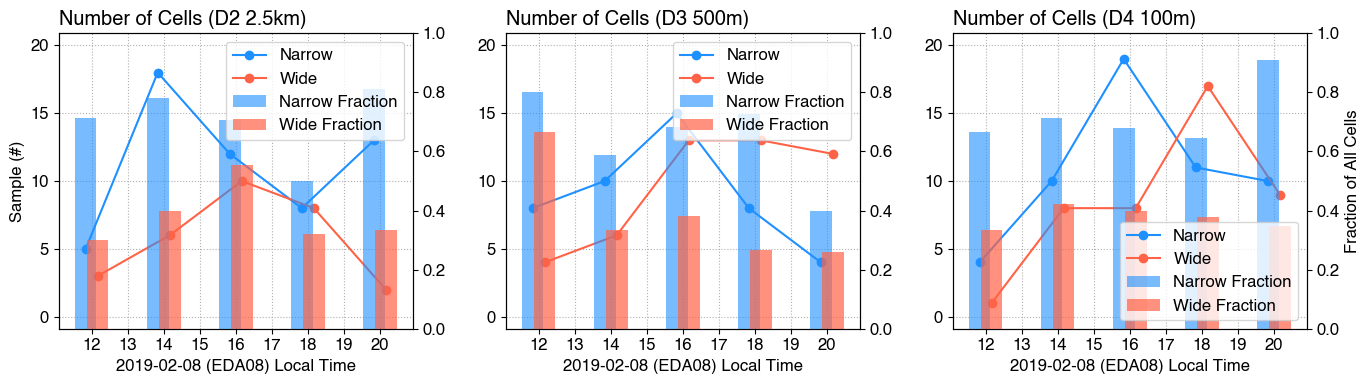

In [450]:
data_arr = [
    [{'n':count_narrow_d2, 'w':count_wide_d2}, 
     {'n':count_narrow_d3, 'w':count_wide_d3}, 
     {'n':count_narrow_d4, 'w':count_wide_d4},]
]
bardata_arr = [
    [{'n':count_narrow_d2/count_allnarrow_d2, 'w':count_wide_d2/count_allwide_d2}, 
     {'n':count_narrow_d3/count_allnarrow_d3, 'w':count_wide_d3/count_allwide_d3}, 
     {'n':count_narrow_d4/count_allnarrow_d4, 'w':count_wide_d4/count_allwide_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['Sample (#)', '', '']]
ylabels2 = [['', '', 'Fraction of All Cells']]
titles = [['Number of Cells (D2 2.5km)', 'Number of Cells (D3 500m)','Number of Cells (D4 100m)']]
# ylims = None
x_offset = 10
bx_offset = 10
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_CellNumber_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_bars=bardata_arr, x_offset=x_offset, bx_offset=bx_offset, 
                     xlabels=xlabels, ylabels=ylabels, ylabels2=ylabels2, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_MaxETH10dbz_d2_d3_d4_20190208_eda08.png


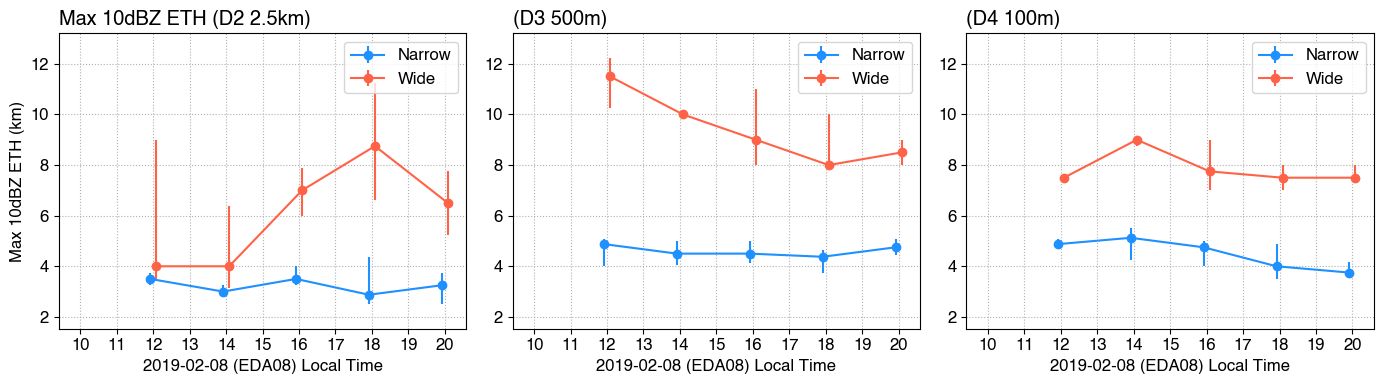

In [451]:
data_arr = [
    [{'n':narrow_maxETH10dbz_d2, 'w':wide_maxETH10dbz_d2}, 
     {'n':narrow_maxETH10dbz_d3, 'w':wide_maxETH10dbz_d3}, 
     {'n':narrow_maxETH10dbz_d4, 'w':wide_maxETH10dbz_d4},]
]
err_arr = [
    [{'n':narrow_maxETH10dbz_err_d2, 'w':wide_maxETH10dbz_err_d2}, 
     {'n':narrow_maxETH10dbz_err_d3, 'w':wide_maxETH10dbz_err_d3}, 
     {'n':narrow_maxETH10dbz_err_d4, 'w':wide_maxETH10dbz_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['Max 10dBZ ETH (km)', '', '']]
titles = [['Max 10dBZ ETH (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
# ylims = (0,20)
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_MaxETH10dbz_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_pELmu_d2_d3_d4_20190208_eda08.png


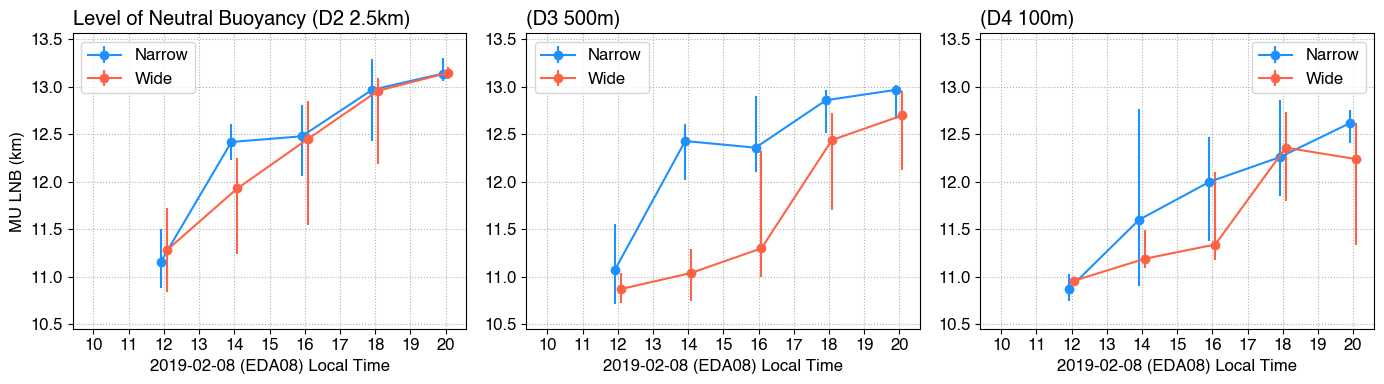

In [452]:
data_arr = [
    [{'n':narrow_pELmu_d2, 'w':wide_pELmu_d2}, 
     {'n':narrow_pELmu_d3, 'w':wide_pELmu_d3}, 
     {'n':narrow_pELmu_d4, 'w':wide_pELmu_d4},]
]
err_arr = [
    [{'n':narrow_pELmu_err_d2, 'w':wide_pELmu_err_d2}, 
     {'n':narrow_pELmu_err_d3, 'w':wide_pELmu_err_d3}, 
     {'n':narrow_pELmu_err_d4, 'w':wide_pELmu_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['MU LNB (km)', '', '']]
titles = [['Level of Neutral Buoyancy (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = (0,20)
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_pELmu_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, 
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_pCAPEmu_d2_d3_d4_20190208_eda08.png


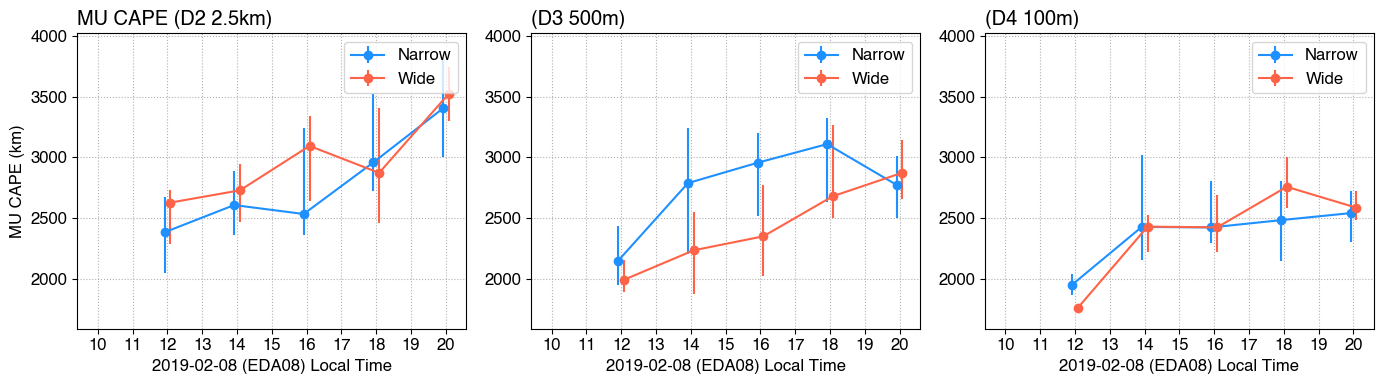

In [453]:
data_arr = [
    [{'n':narrow_pCAPEmu_d2, 'w':wide_pCAPEmu_d2}, 
     {'n':narrow_pCAPEmu_d3, 'w':wide_pCAPEmu_d3}, 
     {'n':narrow_pCAPEmu_d4, 'w':wide_pCAPEmu_d4},]
]
err_arr = [
    [{'n':narrow_pCAPEmu_err_d2, 'w':wide_pCAPEmu_err_d2}, 
     {'n':narrow_pCAPEmu_err_d3, 'w':wide_pCAPEmu_err_d3}, 
     {'n':narrow_pCAPEmu_err_d4, 'w':wide_pCAPEmu_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['MU CAPE (km)', '', '']]
titles = [['MU CAPE (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_pCAPEmu_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_pCAPEacbl_d2_d3_d4_20190208_eda08.png


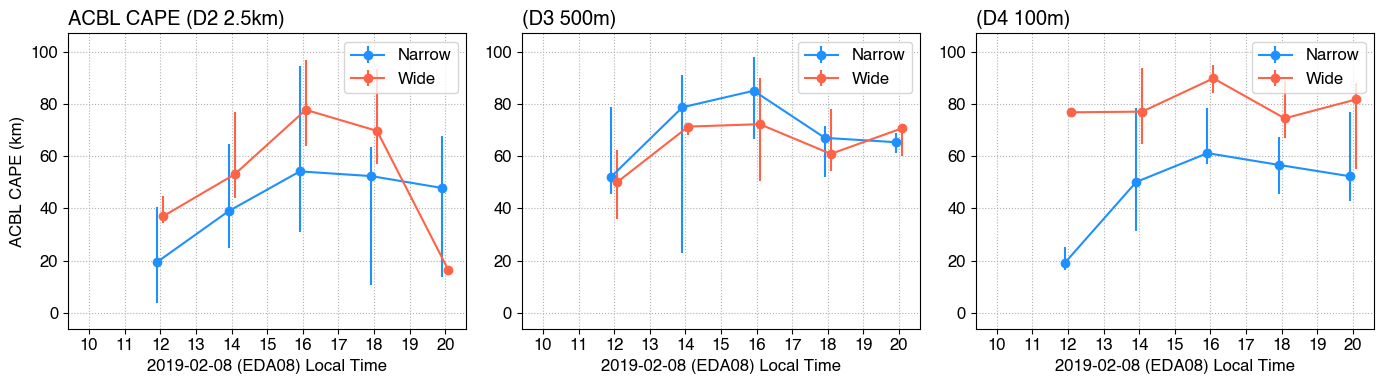

In [454]:
data_arr = [
    [{'n':narrow_pCAPEacbl_d2, 'w':wide_pCAPEacbl_d2}, 
     {'n':narrow_pCAPEacbl_d3, 'w':wide_pCAPEacbl_d3}, 
     {'n':narrow_pCAPEacbl_d4, 'w':wide_pCAPEacbl_d4},]
]
err_arr = [
    [{'n':narrow_pCAPEacbl_err_d2, 'w':wide_pCAPEacbl_err_d2}, 
     {'n':narrow_pCAPEacbl_err_d3, 'w':wide_pCAPEacbl_err_d3}, 
     {'n':narrow_pCAPEacbl_err_d4, 'w':wide_pCAPEacbl_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['ACBL CAPE (km)', '', '']]
titles = [['ACBL CAPE (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_pCAPEacbl_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_LCLz_d2_d3_d4_20190208_eda08.png


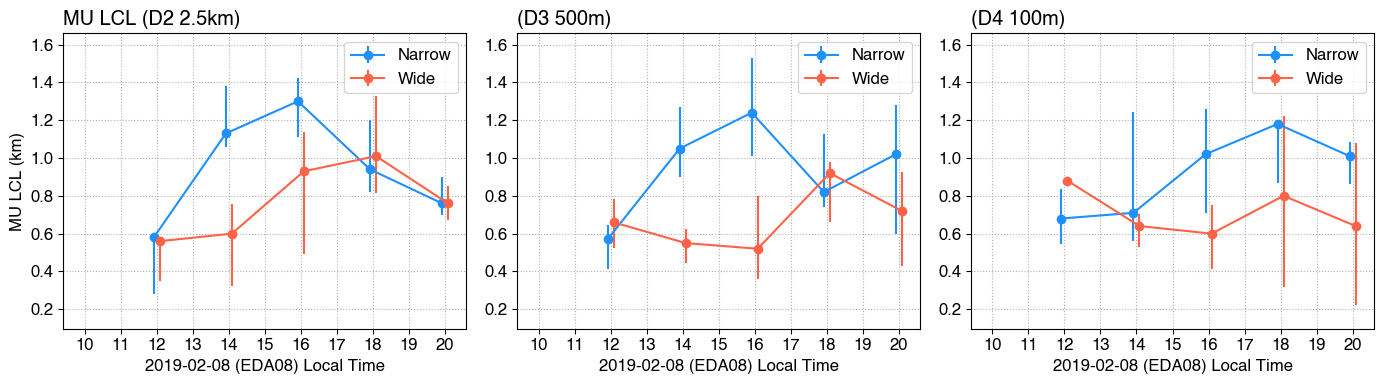

In [455]:
data_arr = [
    [{'n':narrow_LCLz_d2, 'w':wide_LCLz_d2}, 
     {'n':narrow_LCLz_d3, 'w':wide_LCLz_d3}, 
     {'n':narrow_LCLz_d4, 'w':wide_LCLz_d4},]
]
err_arr = [
    [{'n':narrow_LCLz_err_d2, 'w':wide_LCLz_err_d2}, 
     {'n':narrow_LCLz_err_d3, 'w':wide_LCLz_err_d3}, 
     {'n':narrow_LCLz_err_d4, 'w':wide_LCLz_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['MU LCL (km)', '', '']]
titles = [['MU LCL (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_LCLz_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_pLFCz_d2_d3_d4_20190208_eda08.png


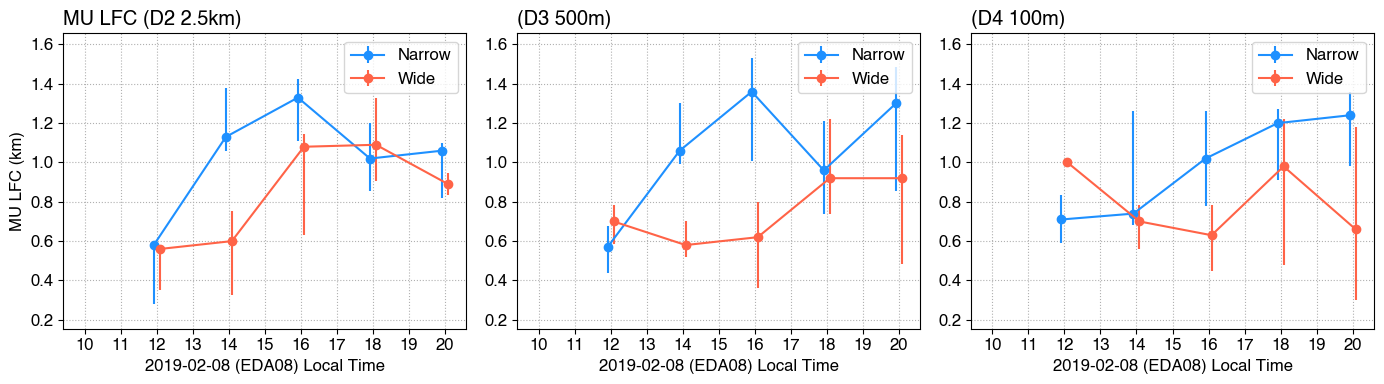

In [456]:
data_arr = [
    [{'n':narrow_pLFCz_d2, 'w':wide_pLFCz_d2}, 
     {'n':narrow_pLFCz_d3, 'w':wide_pLFCz_d3}, 
     {'n':narrow_pLFCz_d4, 'w':wide_pLFCz_d4},]
]
err_arr = [
    [{'n':narrow_pLFCz_err_d2, 'w':wide_pLFCz_err_d2}, 
     {'n':narrow_pLFCz_err_d3, 'w':wide_pLFCz_err_d3}, 
     {'n':narrow_pLFCz_err_d4, 'w':wide_pLFCz_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['MU LFC (km)', '', '']]
titles = [['MU LFC (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_pLFCz_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_RHacbl_d2_d3_d4_20190208_eda08.png


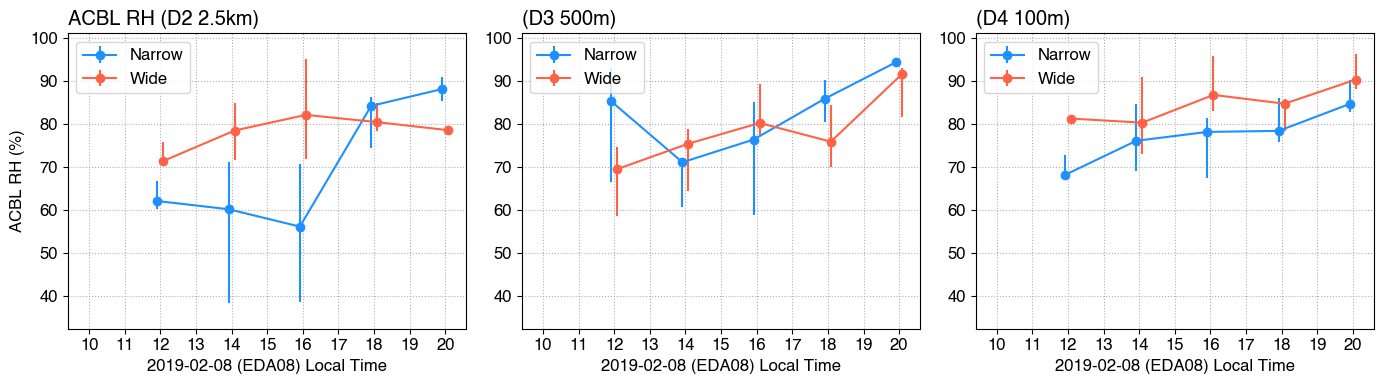

In [457]:
data_arr = [
    [{'n':narrow_RHacbl_d2, 'w':wide_RHacbl_d2}, 
     {'n':narrow_RHacbl_d3, 'w':wide_RHacbl_d3}, 
     {'n':narrow_RHacbl_d4, 'w':wide_RHacbl_d4},]
]
err_arr = [
    [{'n':narrow_RHacbl_err_d2, 'w':wide_RHacbl_err_d2}, 
     {'n':narrow_RHacbl_err_d3, 'w':wide_RHacbl_err_d3}, 
     {'n':narrow_RHacbl_err_d4, 'w':wide_RHacbl_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['ACBL RH (%)', '', '']]
titles = [['ACBL RH (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_RHacbl_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_RH600mb_d2_d3_d4_20190208_eda08.png


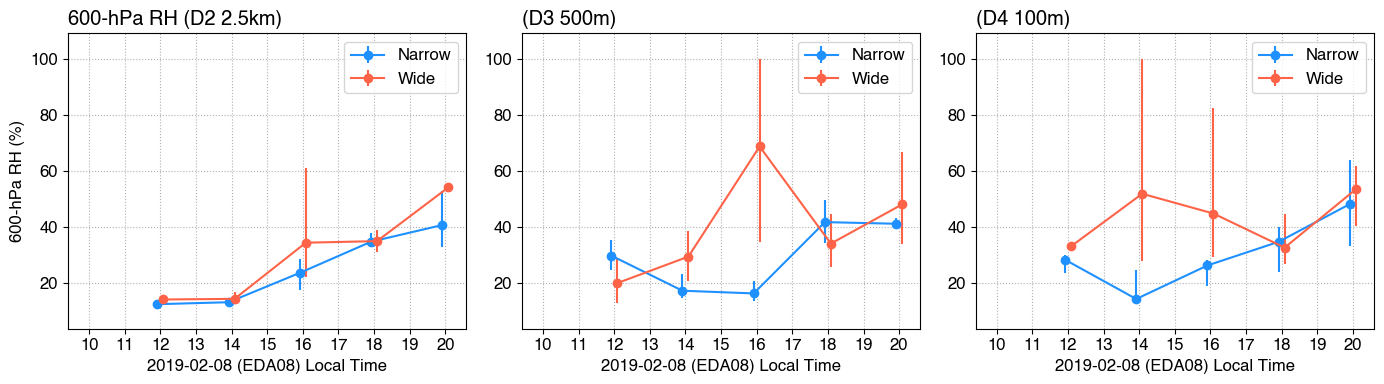

In [458]:
data_arr = [
    [{'n':narrow_RH600mb_d2, 'w':wide_RH600mb_d2}, 
     {'n':narrow_RH600mb_d3, 'w':wide_RH600mb_d3}, 
     {'n':narrow_RH600mb_d4, 'w':wide_RH600mb_d4},]
]
err_arr = [
    [{'n':narrow_RH600mb_err_d2, 'w':wide_RH600mb_err_d2}, 
     {'n':narrow_RH600mb_err_d3, 'w':wide_RH600mb_err_d3}, 
     {'n':narrow_RH600mb_err_d4, 'w':wide_RH600mb_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['600-hPa RH (%)', '', '']]
titles = [['600-hPa RH (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_RH600mb_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_RH500mb_d2_d3_d4_20190208_eda08.png


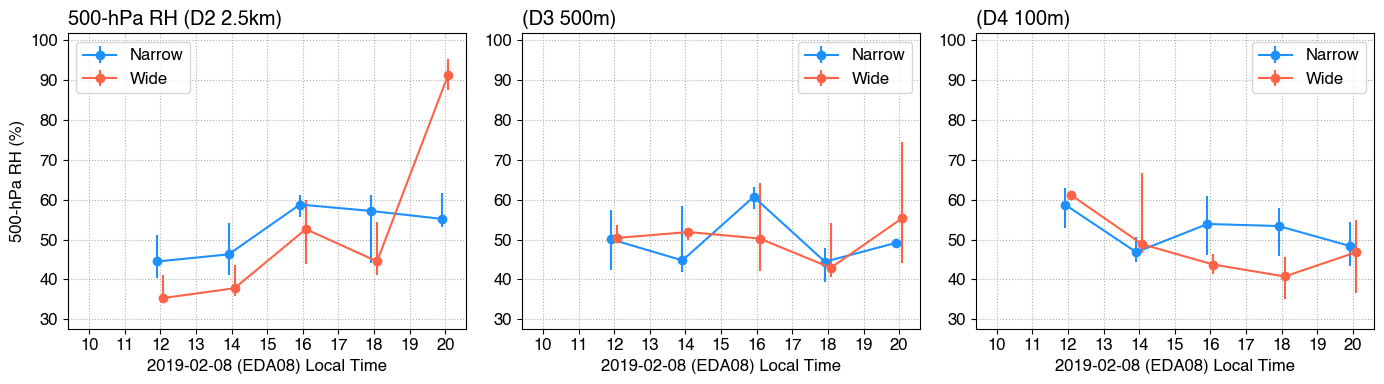

In [459]:
data_arr = [
    [{'n':narrow_RH500mb_d2, 'w':wide_RH500mb_d2}, 
     {'n':narrow_RH500mb_d3, 'w':wide_RH500mb_d3}, 
     {'n':narrow_RH500mb_d4, 'w':wide_RH500mb_d4},]
]
err_arr = [
    [{'n':narrow_RH500mb_err_d2, 'w':wide_RH500mb_err_d2}, 
     {'n':narrow_RH500mb_err_d3, 'w':wide_RH500mb_err_d3}, 
     {'n':narrow_RH500mb_err_d4, 'w':wide_RH500mb_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['500-hPa RH (%)', '', '']]
titles = [['500-hPa RH (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_RH500mb_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_RHlfc1500m_d2_d3_d4_20190208_eda08.png


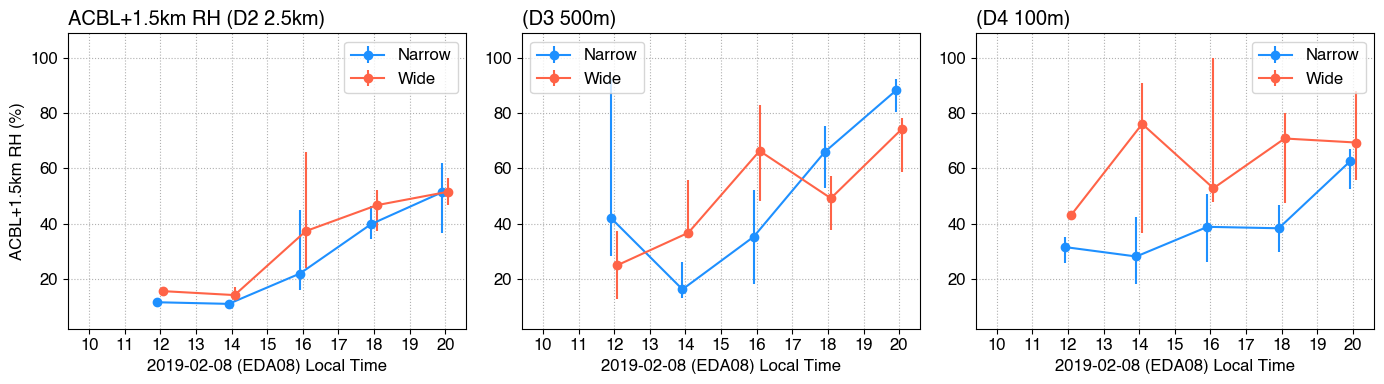

In [460]:
data_arr = [
    [{'n':narrow_RHlfc1500_d2, 'w':wide_RHlfc1500_d2}, 
     {'n':narrow_RHlfc1500_d3, 'w':wide_RHlfc1500_d3}, 
     {'n':narrow_RHlfc1500_d4, 'w':wide_RHlfc1500_d4},]
]
err_arr = [
    [{'n':narrow_RHlfc1500_err_d2, 'w':wide_RHlfc1500_err_d2}, 
     {'n':narrow_RHlfc1500_err_d3, 'w':wide_RHlfc1500_err_d3}, 
     {'n':narrow_RHlfc1500_err_d4, 'w':wide_RHlfc1500_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['ACBL+1.5km RH (%)', '', '']]
titles = [['ACBL+1.5km RH (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_RHlfc1500m_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_PW_d2_d3_d4_20190208_eda08.png


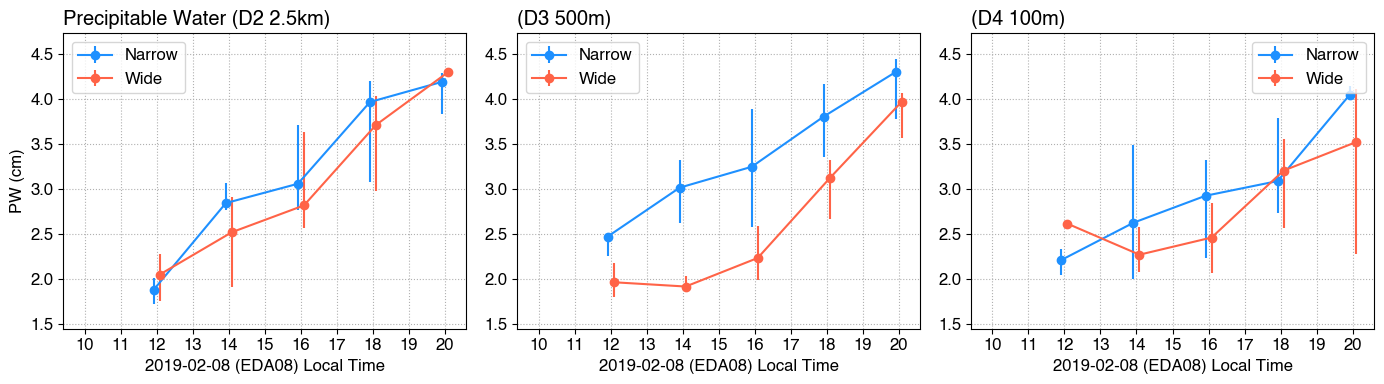

In [461]:
data_arr = [
    [{'n':narrow_PW_d2, 'w':wide_PW_d2}, 
     {'n':narrow_PW_d3, 'w':wide_PW_d3}, 
     {'n':narrow_PW_d4, 'w':wide_PW_d4},]
]
err_arr = [
    [{'n':narrow_PW_err_d2, 'w':wide_PW_err_d2}, 
     {'n':narrow_PW_err_d3, 'w':wide_PW_err_d3}, 
     {'n':narrow_PW_err_d4, 'w':wide_PW_err_d4},]
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
xlabels = [[time_bins_c[0].strftime('%Y-%m-%d')+f' ({ens_member.upper()}) Local Time']*ncol]
ylabels = [['PW (cm)', '', '']]
titles = [['Precipitable Water (D2 2.5km)', '(D3 500m)','(D4 100m)']]
x_offset = 5
ylims = None
fontsize = 12
figsize = (14,4)
figname = f'{figdir}TimeSeries_PW_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = timeseries_mxn(nrow, ncol, data_arr, time_bins_lt, da_err=err_arr, x_offset=x_offset, xlabels=xlabels, ylabels=ylabels, ylims=ylims,
                     titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [462]:
figname

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/TimeSeries_PW_d2_d3_d4_20190208_eda08.png'

In [463]:
def theta_e_bolton(TEMPERATURE, QVAPOR, PRESSURE):
    # theta-e following Bolton (1980); error of < 0.3 K between -35 and 35C; from Thompson scheme
    # more accurate formula from Emanuel could be implemented; ice effects also excluded
    es = PRESSURE*QVAPOR/(0.622*QVAPOR)
    TDEW = (35.86*np.log(es) - 4947.2325)/(np.log(es) - 23.6837)
    TLCL = 1/(1/(TDEW - 56) + np.log(TEMPERATURE/TDEW)/800) + 56
    p1 = 3.376/TLCL - 0.00254
    p2 = 1e3*QVAPOR*(1 + 0.81*QVAPOR)
    THETAE_Bolton = (TEMPERATURE*(100000./PRESSURE)**(0.2854*(1 - 0.28*QVAPOR)))*np.exp(p1*p2) #K
    return THETAE_Bolton

In [464]:
def calc_thetas(ds, preCI_nt):
    # Get T, P, Qv profiles pre-CI
    temp = ds.temperature.sel(times=slice(preCI_nt,0))
    pres = ds.pressure.sel(times=slice(preCI_nt,0))
    qv = ds.qv.sel(times=slice(preCI_nt,0))
    # Compute Theta
    Theta = temp * (1e5 / pres)**0.286
    # Compute ThetaE
    ThetaE = theta_e_bolton(temp, qv, pres)
    return (Theta, ThetaE)

In [465]:
preCI_nt = -12  # number of preCI times

# Calculate Theta & ThetaE
Theta_narrow_d2, ThetaE_narrow_d2 = calc_thetas(ds_narrow_d2, preCI_nt)
Theta_wide_d2, ThetaE_wide_d2 = calc_thetas(ds_wide_d2, preCI_nt)
# # Number of samples in the tracks composite
# ns_narrow_d2 = (ds_narrow_d2.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
# ns_wide_d2 = (ds_wide_d2.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

In [466]:
# Calculate Theta & ThetaE
Theta_narrow_d3, ThetaE_narrow_d3 = calc_thetas(ds_narrow_d3, preCI_nt)
Theta_wide_d3, ThetaE_wide_d3 = calc_thetas(ds_wide_d3, preCI_nt)
# # Number of samples in the tracks composite
# ns_narrow_d3 = (ds_narrow_d3.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
# ns_wide_d3 = (ds_wide_d3.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

In [467]:
# Calculate Theta & ThetaE
Theta_narrow_d4, ThetaE_narrow_d4 = calc_thetas(ds_narrow_d4, preCI_nt)
Theta_wide_d4, ThetaE_wide_d4 = calc_thetas(ds_wide_d4, preCI_nt)
# # Number of samples in the tracks composite
# ns_narrow_d4 = (ds_narrow_d4.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
# ns_wide_d4 = (ds_wide_d4.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

In [468]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

percentiles = [0.25, 0.75]

narrow_RH_d2, narrow_RH_err_d2 = get_timeseries(ds_narrow_d2.rh.sel(times=preCI_time), time_bins, percentiles)
narrow_qv_d2, narrow_qv_err_d2 = get_timeseries(ds_narrow_d2.qv.sel(times=preCI_time), time_bins, percentiles)
narrow_Theta_d2, narrow_Theta_err_d2 = get_timeseries(Theta_narrow_d2.sel(times=preCI_time), time_bins, percentiles)
narrow_ThetaE_d2, narrow_ThetaE_err_d2 = get_timeseries(ThetaE_narrow_d2.sel(times=preCI_time), time_bins, percentiles)

wide_RH_d2, wide_RH_err_d2 = get_timeseries(ds_wide_d2.rh.sel(times=preCI_time), time_bins, percentiles)
wide_qv_d2, wide_qv_err_d2 = get_timeseries(ds_wide_d2.qv.sel(times=preCI_time), time_bins, percentiles)
wide_Theta_d2, wide_Theta_err_d2 = get_timeseries(Theta_wide_d2.sel(times=preCI_time), time_bins, percentiles)
wide_ThetaE_d2, wide_ThetaE_err_d2 = get_timeseries(ThetaE_wide_d2.sel(times=preCI_time), time_bins, percentiles)

In [469]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

narrow_RH_d3, narrow_RH_err_d3 = get_timeseries(ds_narrow_d3.rh.sel(times=preCI_time), time_bins, percentiles)
narrow_qv_d3, narrow_qv_err_d3 = get_timeseries(ds_narrow_d3.qv.sel(times=preCI_time), time_bins, percentiles)
narrow_Theta_d3, narrow_Theta_err_d3 = get_timeseries(Theta_narrow_d3.sel(times=preCI_time), time_bins, percentiles)
narrow_ThetaE_d3, narrow_ThetaE_err_d3 = get_timeseries(ThetaE_narrow_d3.sel(times=preCI_time), time_bins, percentiles)

wide_RH_d3, wide_RH_err_d3 = get_timeseries(ds_wide_d3.rh.sel(times=preCI_time), time_bins, percentiles)
wide_qv_d3, wide_qv_err_d3 = get_timeseries(ds_wide_d3.qv.sel(times=preCI_time), time_bins, percentiles)
wide_Theta_d3, wide_Theta_err_d3 = get_timeseries(Theta_wide_d3.sel(times=preCI_time), time_bins, percentiles)
wide_ThetaE_d3, wide_ThetaE_err_d3 = get_timeseries(ThetaE_wide_d3.sel(times=preCI_time), time_bins, percentiles)

In [470]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

narrow_RH_d4, narrow_RH_err_d4 = get_timeseries(ds_narrow_d4.rh.sel(times=preCI_time), time_bins, percentiles)
narrow_qv_d4, narrow_qv_err_d4 = get_timeseries(ds_narrow_d4.qv.sel(times=preCI_time), time_bins, percentiles)
narrow_Theta_d4, narrow_Theta_err_d4 = get_timeseries(Theta_narrow_d4.sel(times=preCI_time), time_bins, percentiles)
narrow_ThetaE_d4, narrow_ThetaE_err_d4 = get_timeseries(ThetaE_narrow_d4.sel(times=preCI_time), time_bins, percentiles)

wide_RH_d4, wide_RH_err_d4 = get_timeseries(ds_wide_d4.rh.sel(times=preCI_time), time_bins, percentiles)
wide_qv_d4, wide_qv_err_d4 = get_timeseries(ds_wide_d4.qv.sel(times=preCI_time), time_bins, percentiles)
wide_Theta_d4, wide_Theta_err_d4 = get_timeseries(Theta_wide_d4.sel(times=preCI_time), time_bins, percentiles)
wide_ThetaE_d4, wide_ThetaE_err_d4 = get_timeseries(ThetaE_wide_d4.sel(times=preCI_time), time_bins, percentiles)

In [471]:
# fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=100)
# narrow_ThetaE_d2.sel(height=slice(0,10000)).plot.line(y='height', add_legend=False, ax=axes[0])
# wide_ThetaE_d2.sel(height=slice(0,10000)).plot.line(y='height', add_legend=False, ax=axes[1])

In [472]:
# fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=100)
# narrow_qv_d2.sel(height=slice(0,10000)).plot.line(y='height', add_legend=False, ax=axes[0])
# wide_qv_d2.sel(height=slice(0,10000)).plot.line(y='height', add_legend=False, ax=axes[1])

In [473]:
# narrow_ThetaE_d2
time_bins_c

DatetimeIndex(['2019-02-08 13:00:00', '2019-02-08 15:00:00',
               '2019-02-08 17:00:00', '2019-02-08 19:00:00',
               '2019-02-08 21:00:00', '2019-02-08 23:00:00'],
              dtype='datetime64[ns]', freq=None)

## Function to plot profiles

In [474]:
def profiles_mxn(nrow, ncol, da, height, nsamples, n_lines=None, xlabels=None, ylabels=None, xlims=None, ylims=None, titles=None, cmap=None,
                 legend_loc='best', legend_fontsize=None, fontsize=None, suptitle=None, figsize=None, figname=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    t_format = '%H'
    cmap = mpl.cm.get_cmap(cmap)
    # Assign colors from the colormap to each line
    lcolors = [cmap(i / n_lines) for i in range(n_lines)]
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col] if (nrow > 1) else axes[col]
            # Loop over each line
            for i in range(n_lines):
                xx = da[row][col].isel(start_basetime_bins=i)
                ns = nsamples[row][col].isel(start_basetime_bins=i).item()
                label = time_bins_lt[i].strftime('%H LT')
                ax.plot(xx, height, color=lcolors[i], label=f'{label} ({ns:.0f})')

            ax.legend(loc=legend_loc, fontsize=legend_fontsize)
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            if (xlims is not None): ax.set_xlim(xlims[0], xlims[1])
            if (ylims is not None): ax.set_ylim(ylims[0], ylims[1])
            ax.grid(ls=':')

    fig.suptitle(suptitle, fontweight='bold')
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

In [475]:
# Get ThetaE min/max values
zlim = (0,5000)
xmin_n_d2 = narrow_ThetaE_d2.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_n_d3 = narrow_ThetaE_d3.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_n_d4 = narrow_ThetaE_d4.sel(height=slice(zlim[0],zlim[1])).min().item()
xmax_n_d2 = narrow_ThetaE_d2.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_n_d3 = narrow_ThetaE_d3.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_n_d4 = narrow_ThetaE_d4.sel(height=slice(zlim[0],zlim[1])).max().item()
xmin_w_d2 = wide_ThetaE_d2.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_w_d3 = wide_ThetaE_d3.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_w_d4 = wide_ThetaE_d4.sel(height=slice(zlim[0],zlim[1])).min().item()
xmax_w_d2 = wide_ThetaE_d2.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_w_d3 = wide_ThetaE_d3.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_w_d4 = wide_ThetaE_d4.sel(height=slice(zlim[0],zlim[1])).max().item()
xmin = np.nanmin([xmin_n_d2, xmin_n_d3, xmin_n_d4, xmin_w_d2, xmin_w_d3, xmin_w_d4])
xmax = np.nanmax([xmax_n_d2, xmax_n_d3, xmax_n_d4, xmax_w_d2, xmax_w_d3, xmax_w_d4])
print(xmin, xmax)

319.0592041015625 336.8439025878906


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/Profiles_ThetaE_d2_d3_d4_20190208_eda08.png


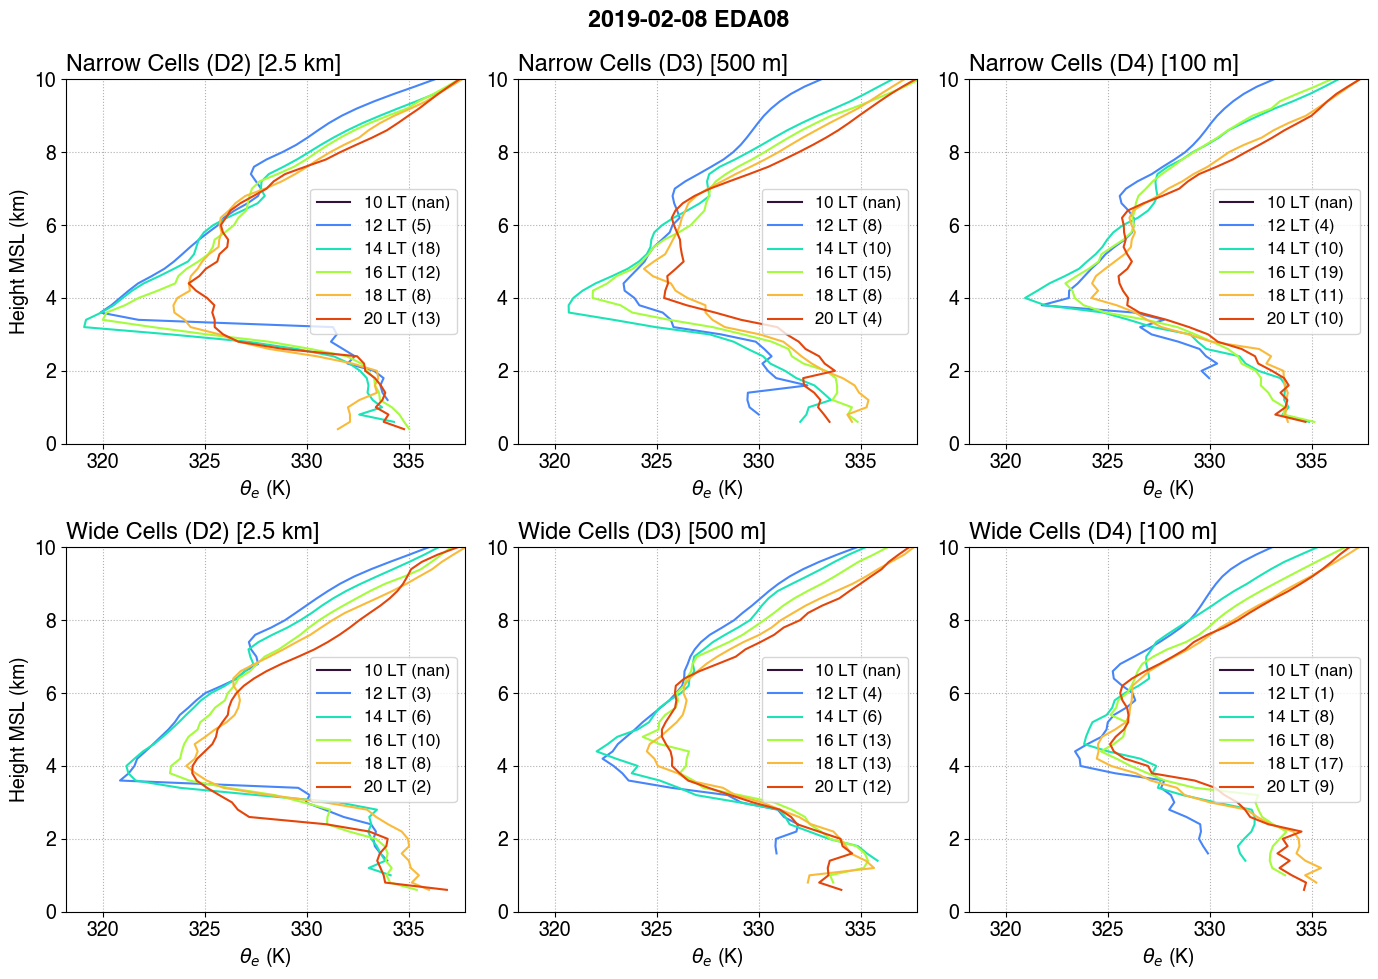

In [476]:
data_arr = [
    [narrow_ThetaE_d2, narrow_ThetaE_d3, narrow_ThetaE_d4],
    [wide_ThetaE_d2, wide_ThetaE_d3, wide_ThetaE_d4],
]
nsamples = [
    [count_narrow_d2, count_narrow_d3, count_narrow_d4],
    [count_wide_d2, count_wide_d3, count_wide_d4],
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
n_lines = len(time_bins_c)
xlabels = [[r'$\theta_e$ '+'(K)']*ncol]*nrow
ylabels = [['Height MSL (km)', '', '']]*nrow
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D3) [500 m]', 'Narrow Cells (D4) [100 m]', ],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D3) [500 m]', 'Wide Cells (D4) [100 m]', ],
]
ylims = (0,10)
xlims = (xmin-(xmax-xmin)*0.05, xmax+(xmax-xmin)*0.05)
# xlims = (325,345)
# xlims = (315,335)
cmap = 'turbo'
fontsize = 14
legend_fontsize = 12
figsize = (14,10)
suptitle = time_bins_c[0].strftime('%Y-%m-%d')+f' {ens_member.upper()}'
figname = f'{figdir}Profiles_ThetaE_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = profiles_mxn(nrow, ncol, data_arr, height, nsamples, n_lines=n_lines, xlims=xlims, ylims=ylims, cmap=cmap, xlabels=xlabels, ylabels=ylabels, titles=titles, 
                   fontsize=fontsize, legend_fontsize=legend_fontsize, suptitle=suptitle, figsize=figsize, figname=figname)

In [477]:
# Get ThetaE min/max values
zlim = (0,10000)
xmin_n_d2 = narrow_Theta_d2.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_n_d3 = narrow_Theta_d3.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_n_d4 = narrow_Theta_d4.sel(height=slice(zlim[0],zlim[1])).min().item()
xmax_n_d2 = narrow_Theta_d2.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_n_d3 = narrow_Theta_d3.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_n_d4 = narrow_Theta_d4.sel(height=slice(zlim[0],zlim[1])).max().item()
xmin_w_d2 = wide_Theta_d2.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_w_d3 = wide_Theta_d3.sel(height=slice(zlim[0],zlim[1])).min().item()
xmin_w_d4 = wide_Theta_d4.sel(height=slice(zlim[0],zlim[1])).min().item()
xmax_w_d2 = wide_Theta_d2.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_w_d3 = wide_Theta_d3.sel(height=slice(zlim[0],zlim[1])).max().item()
xmax_w_d4 = wide_Theta_d4.sel(height=slice(zlim[0],zlim[1])).max().item()
xmin = np.nanmin([xmin_n_d2, xmin_n_d3, xmin_n_d4, xmin_w_d2, xmin_w_d3, xmin_w_d4])
xmax = np.nanmax([xmax_n_d2, xmax_n_d3, xmax_n_d4, xmax_w_d2, xmax_w_d3, xmax_w_d4])
print(xmin, xmax)

305.1656188964844 337.8672790527344


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/Profiles_Theta_d2_d3_d4_20190208_eda08.png


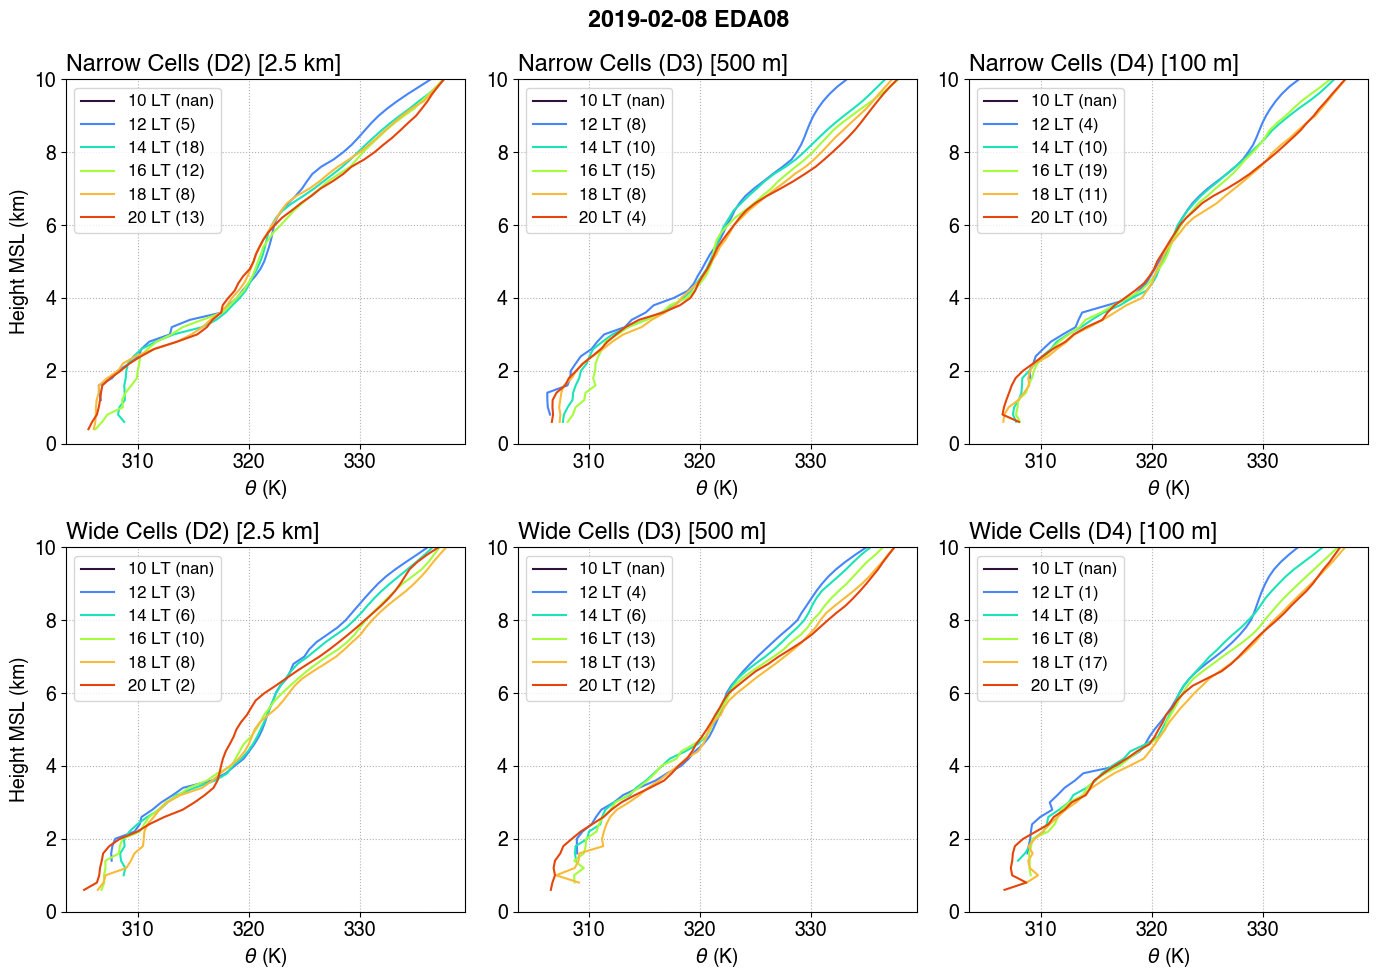

In [478]:
data_arr = [
    [narrow_Theta_d2, narrow_Theta_d3, narrow_Theta_d4],
    [wide_Theta_d2, wide_Theta_d3, wide_Theta_d4],
]
nsamples = [
    [count_narrow_d2, count_narrow_d3, count_narrow_d4],
    [count_wide_d2, count_wide_d3, count_wide_d4],
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
n_lines = len(time_bins_c)
xlabels = [[r'$\theta$ '+'(K)']*ncol]*nrow
ylabels = [['Height MSL (km)', '', '']]*nrow
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D3) [500 m]', 'Narrow Cells (D4) [100 m]', ],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D3) [500 m]', 'Wide Cells (D4) [100 m]', ],
]
ylims = (0,10)
# xlims = (295,350)
xlims = (xmin-(xmax-xmin)*0.05, xmax+(xmax-xmin)*0.05)
cmap = 'turbo'
fontsize = 14
legend_fontsize = 12
figsize = (14,10)
suptitle = time_bins_c[0].strftime('%Y-%m-%d')+f' {ens_member.upper()}'
figname = f'{figdir}Profiles_Theta_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = profiles_mxn(nrow, ncol, data_arr, height, nsamples, n_lines=n_lines, xlims=xlims, ylims=ylims, cmap=cmap, xlabels=xlabels, ylabels=ylabels, titles=titles, 
                   fontsize=fontsize, legend_fontsize=legend_fontsize, suptitle=suptitle, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/20190208_eda08/Profiles_Qv_d2_d3_d4_20190208_eda08.png


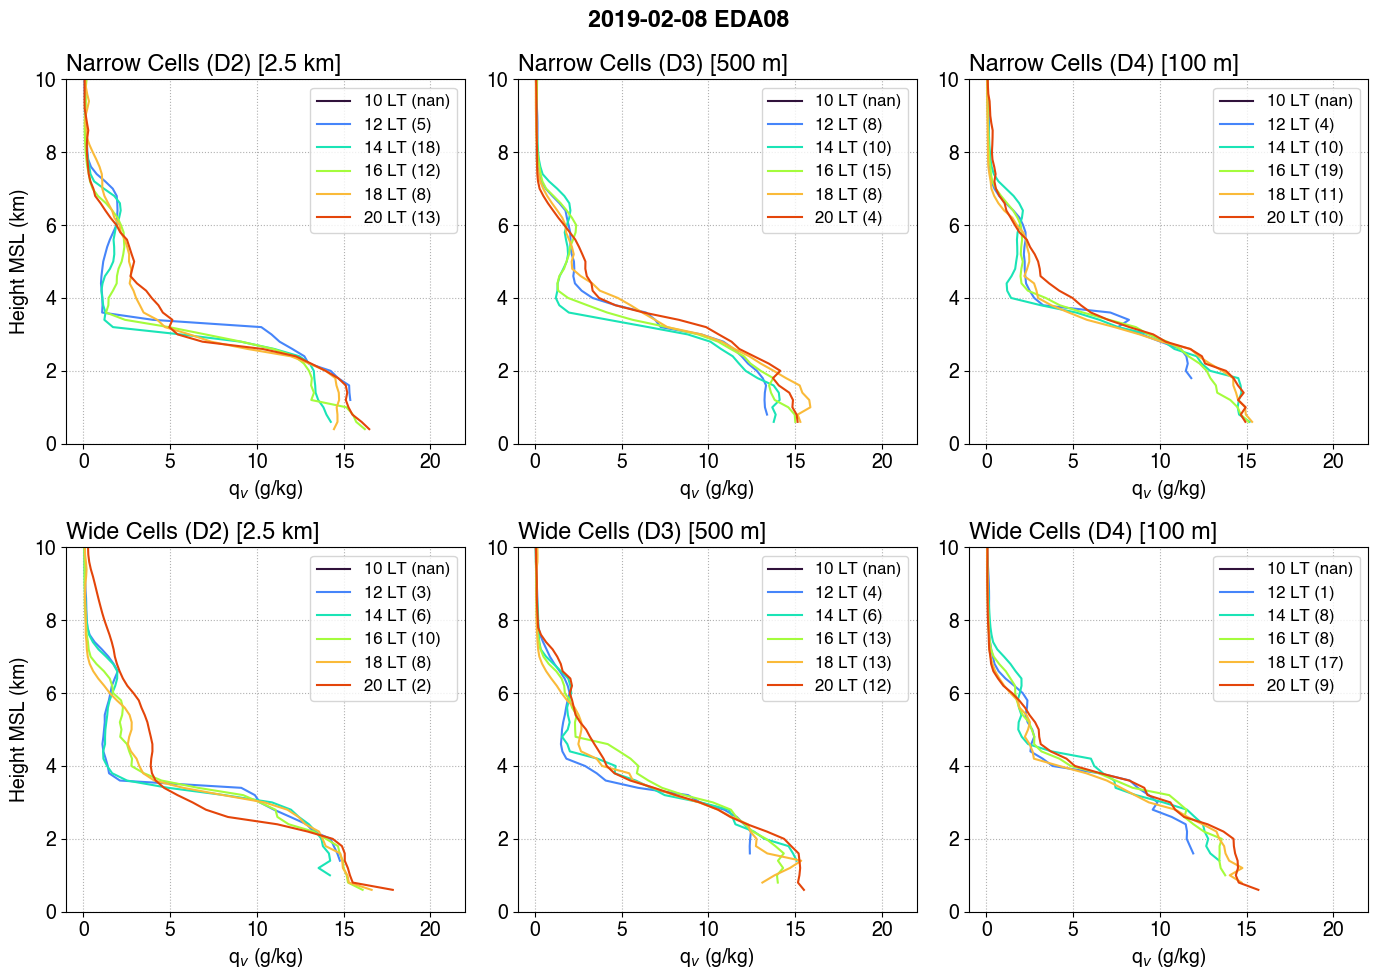

In [479]:
data_arr = [
    [narrow_qv_d2*1000, narrow_qv_d3*1000, narrow_qv_d4*1000],
    [wide_qv_d2*1000, wide_qv_d3*1000, wide_qv_d4*1000],
]
nsamples = [
    [count_narrow_d2, count_narrow_d3, count_narrow_d4],
    [count_wide_d2, count_wide_d3, count_wide_d4],
]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
n_lines = len(time_bins_c)
xlabels = [['q$_{v}$ (g/kg)']*ncol]*nrow
ylabels = [['Height MSL (km)', '', '']]*nrow
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D3) [500 m]', 'Narrow Cells (D4) [100 m]', ],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D3) [500 m]', 'Wide Cells (D4) [100 m]', ],
]
ylims = (0,10)
xlims = (-1,22)
cmap = 'turbo'
fontsize = 14
legend_fontsize = 12
figsize = (14,10)
suptitle = time_bins_c[0].strftime('%Y-%m-%d')+f' {ens_member.upper()}'
figname = f'{figdir}Profiles_Qv_d2_d3_d4_{start_date}_{ens_member}.png'
print(figname)
fig = profiles_mxn(nrow, ncol, data_arr, height, nsamples, n_lines=n_lines, xlims=xlims, ylims=ylims, cmap=cmap, xlabels=xlabels, ylabels=ylabels, titles=titles, 
                   fontsize=fontsize, legend_fontsize=legend_fontsize, suptitle=suptitle, figsize=figsize, figname=figname)